# Mental Health Score Prediction

A machine learning project to predict student mental health scores based on daily screen time, sleep, study habits, physical activity, and stress levels.


## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Silence Optuna logging noise
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 10


## 2. Load and Inspect Dataset

In [2]:
df = pd.read_csv('mental_health_score_dataset.csv')
df.head()


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [3]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Types and Non-Null Counts:")
df.info()


Shape: 5000 rows, 13 columns

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), i

In [4]:
print("Missing values per column:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:
 Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

Duplicate rows: 2


In [5]:
df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,20.82180,1.736620,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,5000.0,5.07846,1.653913,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,5000.0,171.45260,42.858254,62.0,140.0,171.0,204.0,273.0
Study_Hours,5000.0,3.00842,1.637018,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,5000.0,1.75100,0.668398,-0.4,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,5000.0,6.63458,1.221391,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,5000.0,6.23098,1.278701,3.6,5.1,6.1,7.1,9.4


## 3. Data Cleaning and Anomaly Correction

The Physical_Activity_Hours column contains a small number of negative values. Because physical activity cannot be negative, we bound these rows at zero hours.


In [6]:
negative_activity = df[df['Physical_Activity_Hours'] < 0]
print(f"Rows with negative physical activity: {len(negative_activity)}")
negative_activity[['Age', 'Gender', 'Physical_Activity_Hours', 'Stress_Level', 'Mental_Health_Score']].head()


Rows with negative physical activity: 10


,Age,Gender,Physical_Activity_Hours,Stress_Level,Mental_Health_Score
2277,20,Male,-0.1,Very High,4.6
2923,23,Female,-0.1,Very High,5.2
3056,19,Male,-0.3,Very High,4.3
3422,24,Male,-0.1,Very High,4.4
3882,20,Female,-0.2,Very High,5.7


In [7]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)
print(f"Minimum physical activity hours after clipping: {df['Physical_Activity_Hours'].min()}")


Minimum physical activity hours after clipping: 0.0


## 4. Exploratory Data Analysis (EDA)

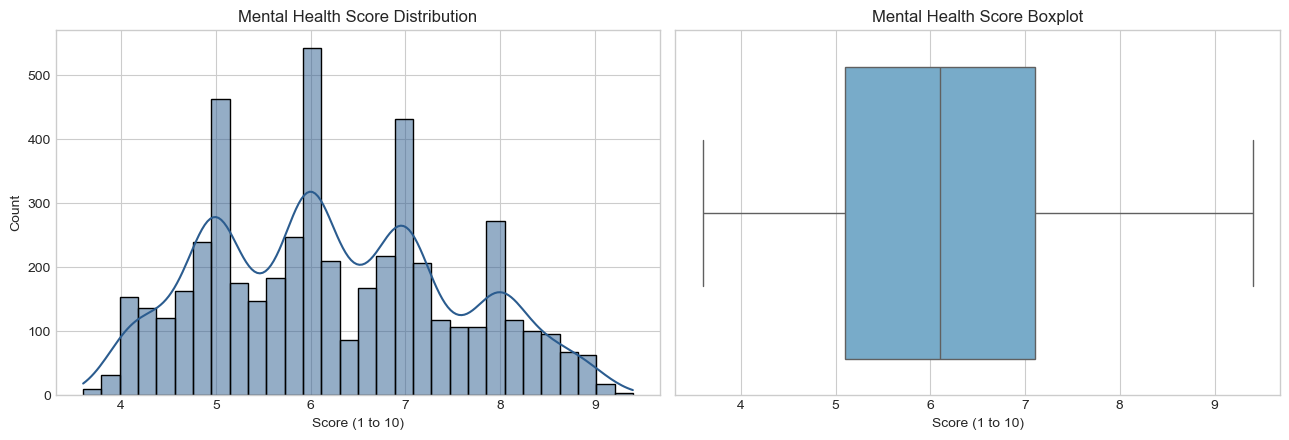

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['Mental_Health_Score'], kde=True, bins=30, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Mental Health Score Distribution')
axes[0].set_xlabel('Score (1 to 10)')

sns.boxplot(x=df['Mental_Health_Score'], ax=axes[1], color='#6baed6')
axes[1].set_title('Mental Health Score Boxplot')
axes[1].set_xlabel('Score (1 to 10)')
plt.tight_layout()
plt.show()


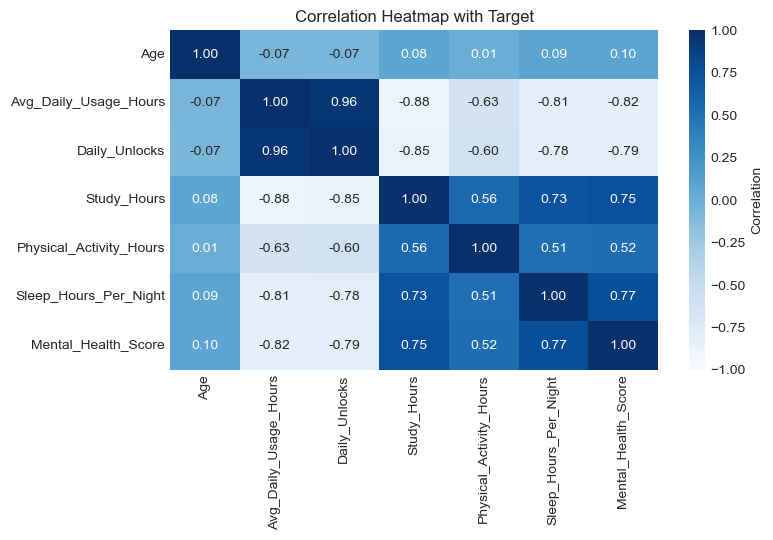

In [9]:
num_features = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
corr = df[num_features].corr()

plt.figure(figsize=(8, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap with Target')
plt.tight_layout()
plt.show()


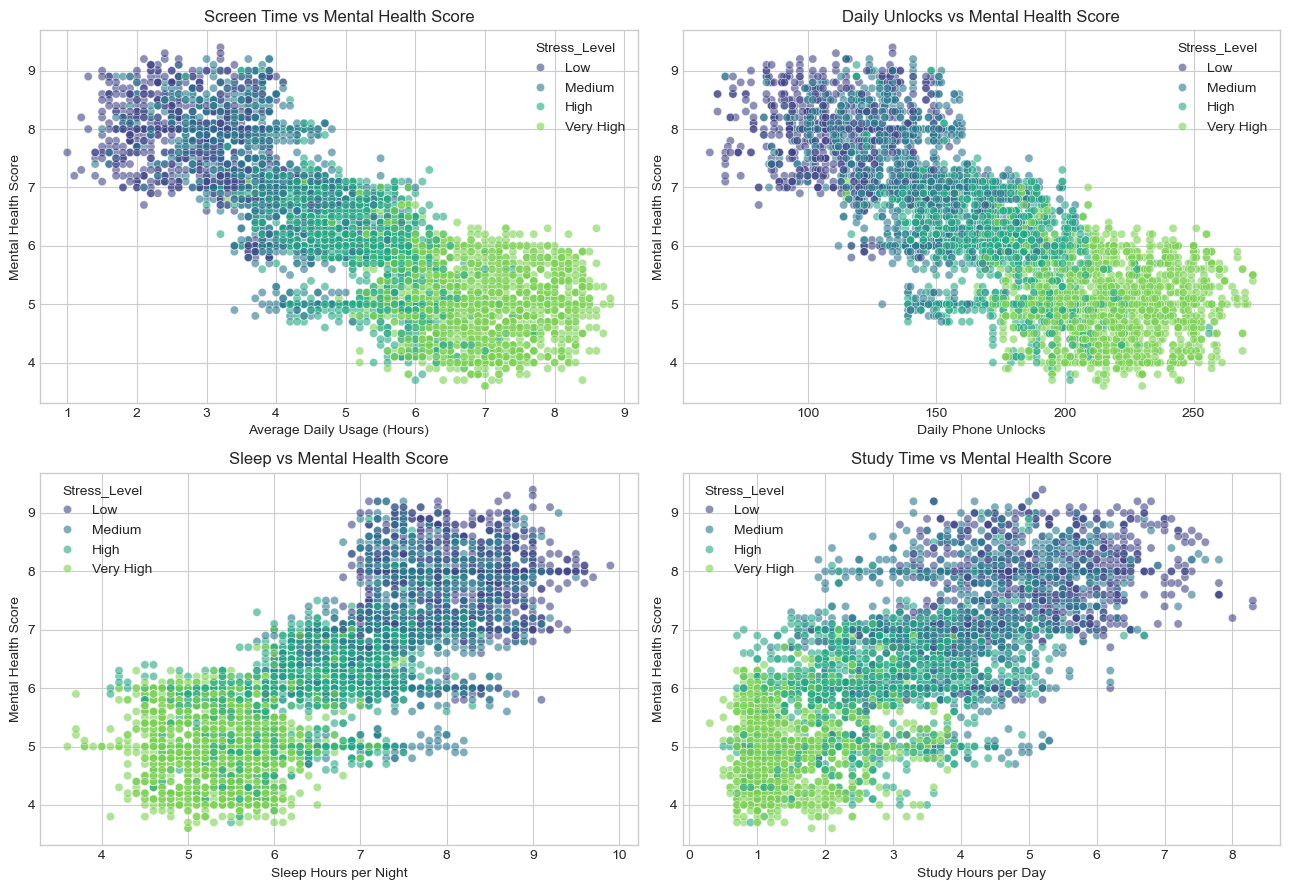

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', hue='Stress_Level', 
                hue_order=['Low', 'Medium', 'High', 'Very High'], palette='viridis', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Screen Time vs Mental Health Score')
axes[0, 0].set_xlabel('Average Daily Usage (Hours)')
axes[0, 0].set_ylabel('Mental Health Score')

sns.scatterplot(data=df, x='Daily_Unlocks', y='Mental_Health_Score', hue='Stress_Level', 
                hue_order=['Low', 'Medium', 'High', 'Very High'], palette='viridis', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Daily Unlocks vs Mental Health Score')
axes[0, 1].set_xlabel('Daily Phone Unlocks')
axes[0, 1].set_ylabel('Mental Health Score')

sns.scatterplot(data=df, x='Sleep_Hours_Per_Night', y='Mental_Health_Score', hue='Stress_Level', 
                hue_order=['Low', 'Medium', 'High', 'Very High'], palette='viridis', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('Sleep vs Mental Health Score')
axes[1, 0].set_xlabel('Sleep Hours per Night')
axes[1, 0].set_ylabel('Mental Health Score')

sns.scatterplot(data=df, x='Study_Hours', y='Mental_Health_Score', hue='Stress_Level', 
                hue_order=['Low', 'Medium', 'High', 'Very High'], palette='viridis', alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('Study Time vs Mental Health Score')
axes[1, 1].set_xlabel('Study Hours per Day')
axes[1, 1].set_ylabel('Mental Health Score')

plt.tight_layout()
plt.show()


/var/folders/_d/3x9m348j6b98bgrrn4t8ryyw0000gn/T/ipykernel_3082/3692788990.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Stress_Level', y='Mental_Health_Score', order=['Low', 'Medium', 'High', 'Very High'], palette='Blues_r', ax=axes[0])
/var/folders/_d/3x9m348j6b98bgrrn4t8ryyw0000gn/T/ipykernel_3082/3692788990.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['Most_Used_Platform'].isin(top_platforms)], x='Most_Used_Platform', y='Mental_Health_Score', palette='mako', ax=axes[1])


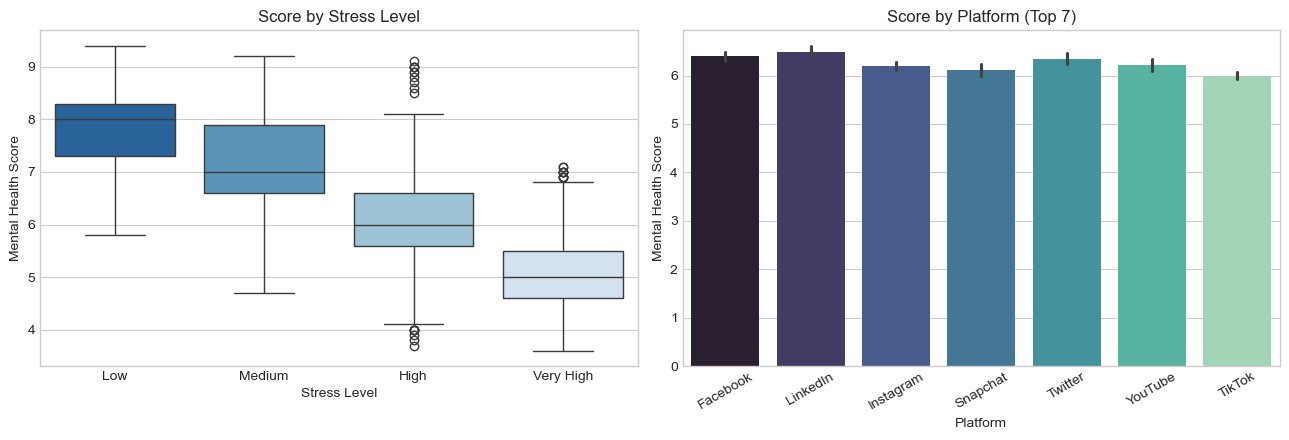

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x='Stress_Level', y='Mental_Health_Score', order=['Low', 'Medium', 'High', 'Very High'], palette='Blues_r', ax=axes[0])
axes[0].set_title('Score by Stress Level')
axes[0].set_xlabel('Stress Level')
axes[0].set_ylabel('Mental Health Score')

top_platforms = df['Most_Used_Platform'].value_counts().index[:7]
sns.barplot(data=df[df['Most_Used_Platform'].isin(top_platforms)], x='Most_Used_Platform', y='Mental_Health_Score', palette='mako', ax=axes[1])
axes[1].set_title('Score by Platform (Top 7)')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Mental Health Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 5. Train-Test Split and Preprocessing Pipeline

We split the dataset into an 80% training split and a 20% test holdout split.
All categorical features, including Country (which contains 111 unique values), are processed using OneHotEncoder with min_frequency=0.015 and handle_unknown='infrequent_if_exist'. This learns category distributions purely on the training folds and avoids data leakage.


In [12]:
num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ord_cols = ['Stress_Level']
cat_cols = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use']

X = df[num_cols + ord_cols + cat_cols]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 4000
Testing samples:  1000


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]), ord_cols),
        ('cat', OneHotEncoder(min_frequency=0.015, handle_unknown='infrequent_if_exist', sparse_output=False), cat_cols)
    ]
)
preprocessor


,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## 6. 4-Model Comparison with 5-Fold Cross Validation

We benchmark four models across identical 5-fold cross-validation splits:
1. Ridge Regression (regularized linear model)
2. Support Vector Regressor (SVR with RBF kernel)
3. Random Forest Regressor (bagging ensemble)
4. XGBoost Regressor (gradient boosting)


In [14]:
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Support Vector Regressor': SVR(C=1.0, epsilon=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regressor': xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=kf,
        scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
        return_train_score=True
    )
    cv_summary.append({
        'Model': name,
        'Train R2': cv_scores['train_r2'].mean(),
        'CV R2 (Mean)': cv_scores['test_r2'].mean(),
        'CV R2 (Std)': cv_scores['test_r2'].std(),
        'CV MAE': -cv_scores['test_neg_mean_absolute_error'].mean(),
        'CV RMSE': -cv_scores['test_neg_root_mean_squared_error'].mean()
    })

cv_df = pd.DataFrame(cv_summary).sort_values(by='CV R2 (Mean)', ascending=False).reset_index(drop=True)
cv_df


,Model,Train R2,CV R2 (Mean),CV R2 (Std),CV MAE,CV RMSE
0,Random Forest,0.982965,0.878535,0.008542,0.322771,0.441442
1,Support Vector Regressor,0.850579,0.814945,0.010448,0.409255,0.545201
2,XGBoost Regressor,0.838411,0.811230,0.009347,0.431380,0.550584
3,Ridge Regression,0.739292,0.731765,0.012838,0.522923,0.656287


/var/folders/_d/3x9m348j6b98bgrrn4t8ryyw0000gn/T/ipykernel_3082/1951610779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cv_df, x='Model', y='CV R2 (Mean)', palette='Blues_r', ax=ax)


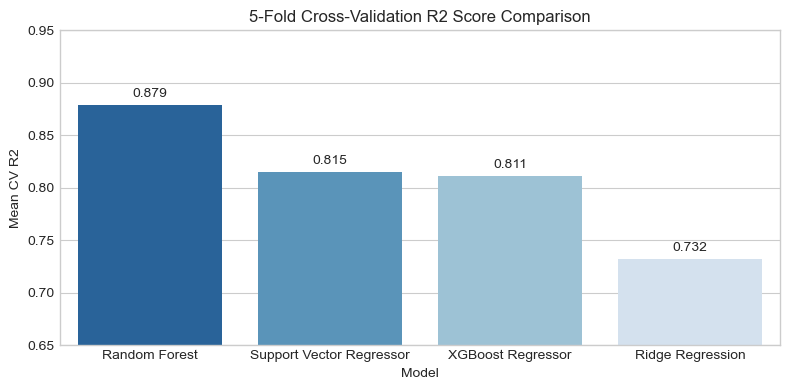

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=cv_df, x='Model', y='CV R2 (Mean)', palette='Blues_r', ax=ax)
ax.set_title('5-Fold Cross-Validation R2 Score Comparison')
ax.set_ylabel('Mean CV R2')
ax.set_ylim(0.65, 0.95)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.008), ha='center')
plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning with Optuna Bayesian Optimization

We tune Random Forest hyperparameters using Optuna with a Tree-structured Parzen Estimator (TPE) sampler across 5-fold cross-validation.


In [16]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 250, step=50)
    max_depth = trial.suggest_int('max_depth', 10, 22)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 8)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 0.8, 1.0])
    
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', rf)])
    scores = cross_validate(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    return scores['test_score'].mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, timeout=120)

print("Optuna Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest Optuna 5-Fold CV R2: {study.best_value:.4f}")


Optuna Best Hyperparameters:
  n_estimators: 200
  max_depth: 18
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: 0.8

Best Optuna 5-Fold CV R2: 0.8782


## 8. Final Test Holdout Evaluation and Diagnostics

We fit the optimal model on the entire training split and evaluate on the untouched test holdout set (1,000 samples).


In [17]:
best_rf = RandomForestRegressor(**study.best_params, random_state=42)
best_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', best_rf)])
best_pipeline.fit(X_train, y_train)

y_test_pred = best_pipeline.predict(X_test)
y_train_pred = best_pipeline.predict(X_train)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R2: {train_r2:.4f}")
print(f"Test R2:  {test_r2:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE:{test_rmse:.4f}")


Train R2: 0.9735
Test R2:  0.9008
Test MAE: 0.3072
Test RMSE:0.4148


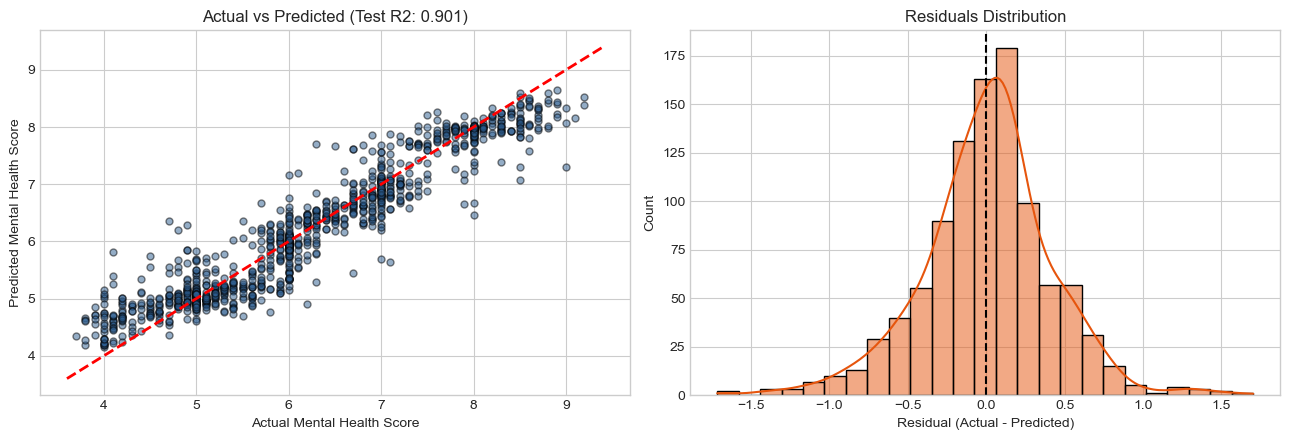

In [18]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_test, y_test_pred, alpha=0.5, color='#2b5c8f', edgecolors='k', s=25)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted (Test R2: {test_r2:.3f})')
axes[0].set_xlabel('Actual Mental Health Score')
axes[0].set_ylabel('Predicted Mental Health Score')

sns.histplot(residuals, kde=True, bins=25, color='#e6550d', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()


## 9. Model Interpretability & Partial Dependence Analysis

We compute tree feature importances and Partial Dependence Plots (PDP) to visualize non-linear threshold dynamics for sleep and screen usage.


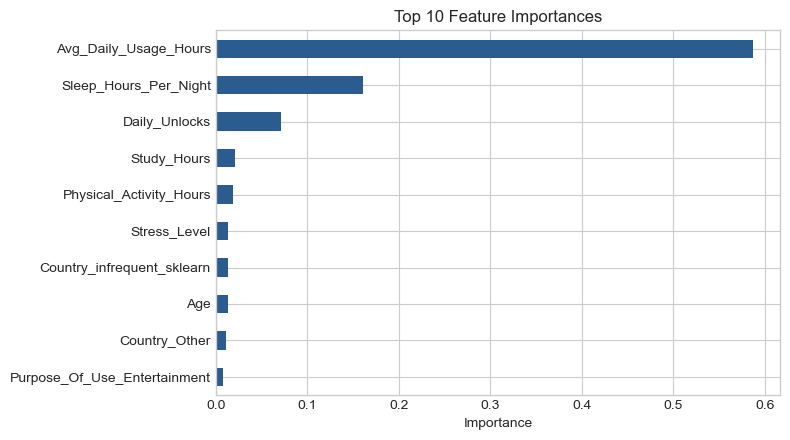

In [19]:
rf_regressor = best_pipeline.named_steps['regressor']
preprocessor_step = best_pipeline.named_steps['preprocessor']

cat_feature_names = preprocessor_step.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + ord_cols + list(cat_feature_names)

importances = rf_regressor.feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4.5))
feat_imp.plot(kind='barh', color='#2b5c8f')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


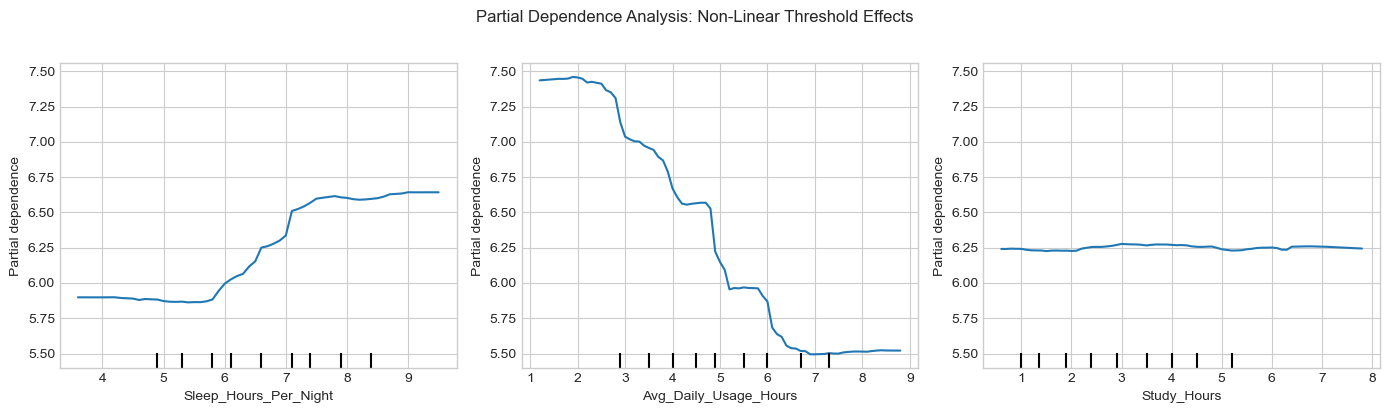

In [20]:
# Partial Dependence Plots for primary continuous drivers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    best_pipeline,
    X_train.sample(500, random_state=42),
    features=['Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours', 'Study_Hours'],
    ax=axes
)
plt.suptitle('Partial Dependence Analysis: Non-Linear Threshold Effects', y=1.02)
plt.tight_layout()
plt.show()


## 10. Pipeline Export and Verification

We save the complete fitted pipeline to disk using joblib and test inference on a sample record.


In [21]:
model_filename = 'mental_health_pipeline.joblib'
joblib.dump(best_pipeline, model_filename)
print(f"Pipeline saved to {model_filename}")


Pipeline saved to mental_health_pipeline.joblib


In [22]:
loaded_pipeline = joblib.load(model_filename)

sample_input = pd.DataFrame([{
    'Age': 21,
    'Gender': 'Female',
    'Country': 'India',
    'Academic_Level': 'Undergraduate',
    'Most_Used_Platform': 'LinkedIn',
    'Purpose_Of_Use': 'Education',
    'Avg_Daily_Usage_Hours': 2.5,
    'Daily_Unlocks': 90,
    'Study_Hours': 5.5,
    'Physical_Activity_Hours': 2.0,
    'Sleep_Hours_Per_Night': 8.0,
    'Stress_Level': 'Low'
}])

pred = loaded_pipeline.predict(sample_input)[0]
print(f"Sample Student Prediction: {pred:.2f} / 10.0")


Sample Student Prediction: 7.82 / 10.0
